<a href="https://colab.research.google.com/github/MelwinKalayil/Cortex/blob/main/VisDroneDetectionTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Fri Sep 18 05:28:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 2.9 MB/s eta 0:00:00


In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="wDZ8p6ZFYkYbffXAnwGc")
project = rf.workspace("uogolanrewaju").project("visdrone2019-det")
version = project.version(4)
dataset = version.download("yolov8")

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to VisDrone2019-DET-4 in yolov8:: 100%|██████████| 17264/17264 [00:12<00:00, 1385.66it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Dataset downloaded to: /content/VisDrone2019-DET-4


In [4]:
from ultralytics import YOLO

# Load the lightweight pretrained Nano model
model = YOLO("yolov8n.pt")

# Train the model
results = model.train(
    data=f"{dataset.location}/data.yaml",
        epochs=50,
            imgsz=640,
                batch=16,
                    device=0,         # 0 selects Colab's GPU
                        workers=4,
                            name="visdrone_yolov8n"
                            )

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VisDrone2019-DET-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_yolov8n, nbs=64, nms=None, op

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2815.8±632.3 MB/s, size: 127.3 KB)
val: Scanning /content/VisDrone2019-DET-4/valid/labels.cache... 547 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 547/547 163.9Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.9it/s 12.2s
                   all        547      38719       0.43      0.322      0.298      0.168
       awning-tricycle        219        530      0.258      0.134      0.103     

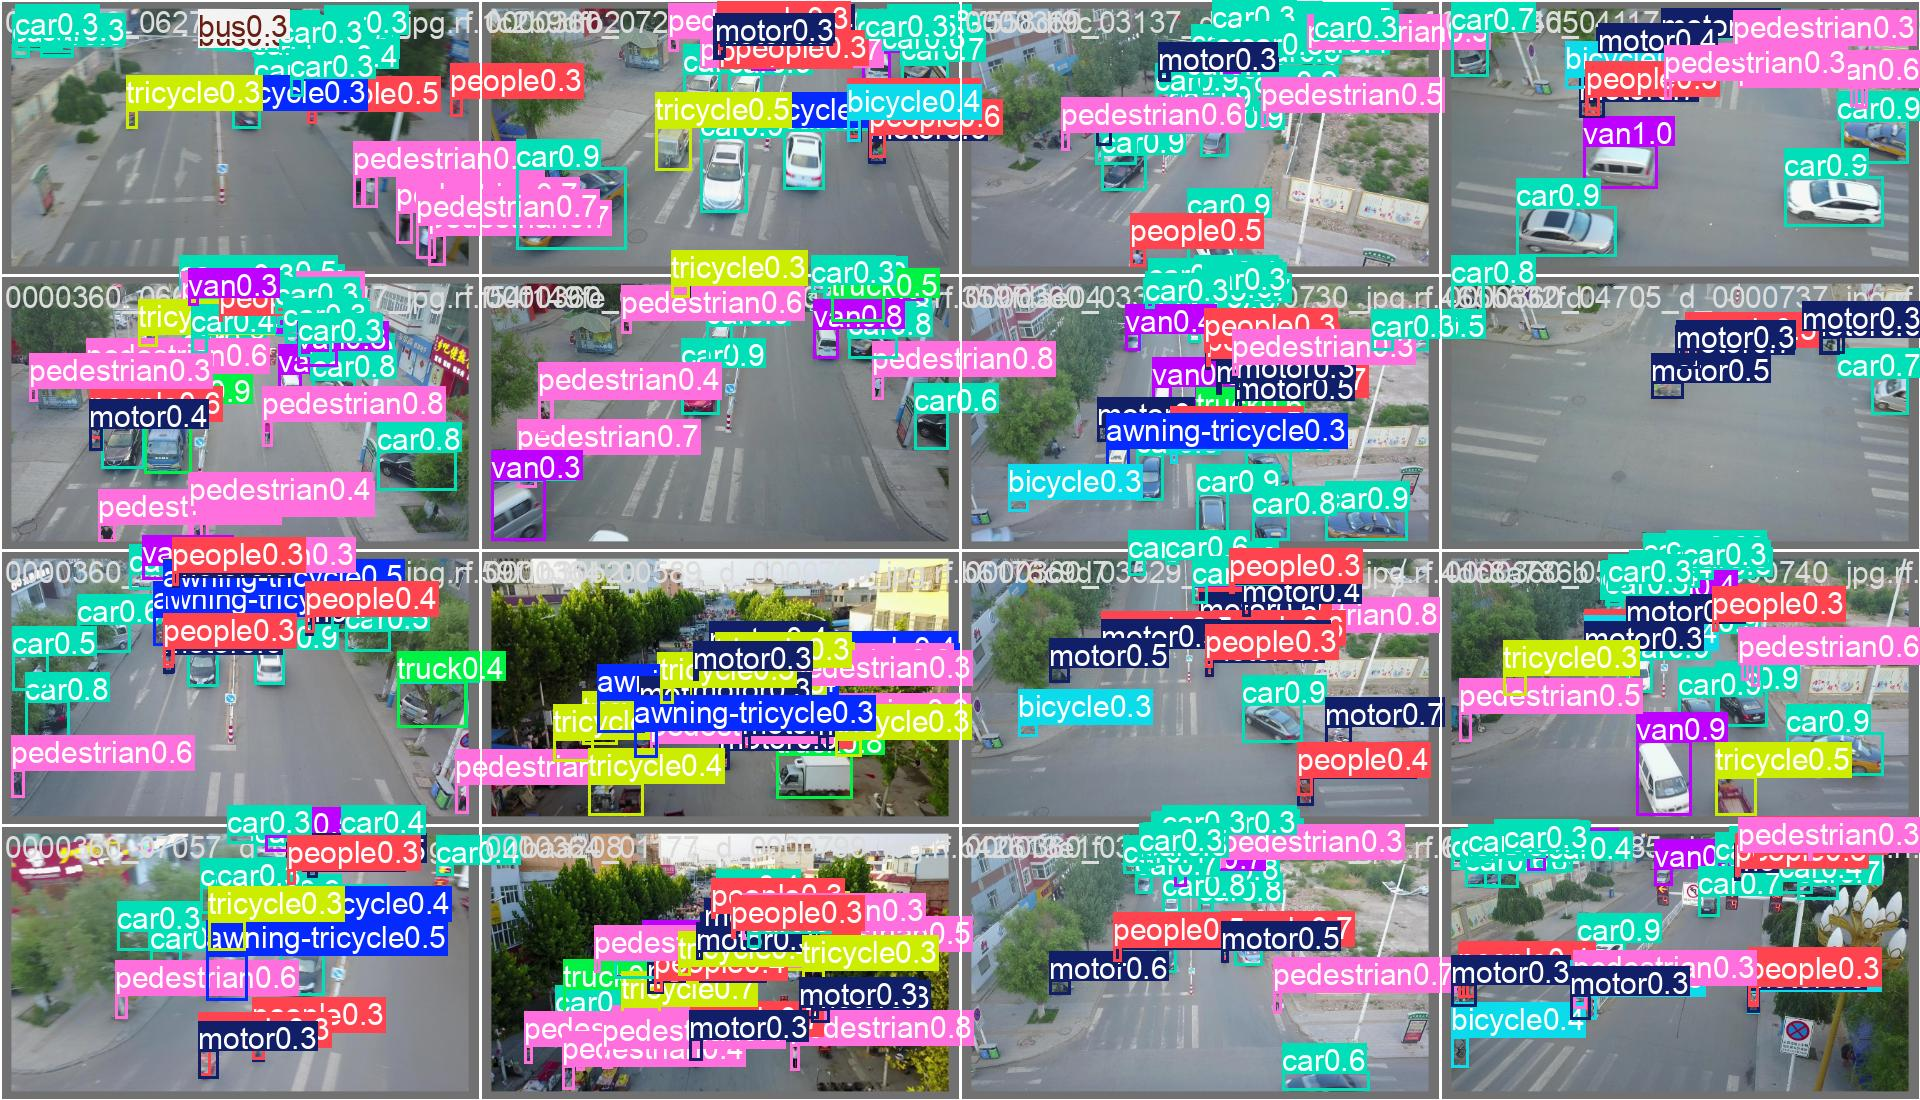

In [5]:
# Evaluate performance metrics (mAP50, mAP50-95)
metrics = model.val()

# Display a sample batch of predictions
from IPython.display import Image
Image(filename="runs/detect/visdrone_yolov8n/val_batch0_pred.jpg")

In [6]:
# Path to best trained weights
best_model = YOLO("runs/detect/visdrone_yolov8n/weights/best.pt")

# 1. Export to ONNX (Standard portable format, best with onnxruntime)
best_model.export(format="onnx", imgsz=640, dynamic=False)

# 2. Export to NCNN (Highly optimized for ARM CPUs like the Pi 5)
best_model.export(format="ncnn", imgsz=640)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/visdrone_yolov8n/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 534ms
Prepared 4 packages in 1.03s
Installed 4 packages in 242ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 2.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming wi

'runs/detect/visdrone_yolov8n/weights/best_ncnn_model'

In [7]:
from google.colab import files

# Download best.pt
files.download("runs/detect/visdrone_yolov8n/weights/best.pt")

# Download best.onnx
files.download("runs/detect/visdrone_yolov8n/weights/best.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import shutil
from google.colab import files

# 1. Zip the entire 'runs' directory
print("Compressing runs folder...")
shutil.make_archive('all_training_runs', 'zip', '/content/runs')

# 2. Trigger browser download
print("Starting download...")
files.download('all_training_runs.zip')

Compressing runs folder...
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="wDZ8p6ZFYkYbffXAnwGc")
project = rf.workspace("cpe313-advanced-ml-and-deep-learning").project("fire-and-smoke-mbhix")
version = project.version(6)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-6 in yolov8:: 100%|██████████| 18044/18044 [00:05<00:00, 3544.36it/s]


In [ ]:
from ultralytics import YOLO

fire_model = YOLO("yolov8n.pt")
fire_results = fire_model.train(
    data=f"{dataset.location}/data.yaml",
        epochs=35,
            imgsz=640,
                batch=16,
                    device=0,
                        workers=4,
                            name="fire_smoke_yolov8n"
                            )
best_fire_model = YOLO("runs/detect/fire_smoke_yolov8n/weights/best.pt")
best_fire_model.export(format="onnx", imgsz=640)

# 5. Download weights to local machine
from google.colab import files
files.download("runs/detect/fire_smoke_yolov8n/weights/best.onnx")